# ISGT Plots — Improved Composite Figures



New plots:

1. **Composite training curves** — 3 cases overlaid in one figure.

2. **Composite cumulative reward** — grouped bars + Gini index.

3. **Daily community energy summary** — overlapping bars, 3 cases side by side + P2P utilization %.

In [1]:
"""
ISGT Plots — Improved composite figures for the paper.

New plots:
1. Composite training curves (3 cases in one plot)
2. Composite cumulative reward per agent (3 cases, grouped bars + Gini index)
3. Community energy metrics with P2P utilization percentages per hour
"""

import ast
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec

## Style configuration

In [2]:
# ═══════════════════════════════════════════════════════════════════════
# Style — IEEE / Springer–friendly, grayscale–safe palette

## Colour palette

In [3]:
# ═══════════════════════════════════════════════════════════════════════
plt.rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "DejaVu Serif"],
    "font.size":         12,
    "axes.titlesize":    11,
    "axes.labelsize":    11,
    "legend.fontsize":   10,
    "xtick.labelsize":   11,
    "ytick.labelsize":   11,
    "figure.dpi":        300,
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linewidth":    0.5,
    "axes.linewidth":    0.8,
    "lines.linewidth":   1.5,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

## Data loaders

In [4]:
# ═══════════════════════════════════════════════════════════════════════
# Colour palette (distinguishable in colour & grayscale)

## Gini coefficient

In [5]:
# ═══════════════════════════════════════════════════════════════════════
CASE_COLORS  = ["#2166ac", "#b2182b", "#1b7837"]   # blue, red, green
CASE_LABELS  = [
    "Scenario 1",
    "Scenario 2",
    "Scenario 3",
]
AGENT_CMAP = plt.colormaps.get_cmap("tab10")

ENERGY_PALETTE = {
    "generation_total": ("#4daf4a", "Generation"),
    "demand_total":     ("#e41a1c", "Demand"),
    "total_p2p":        ("#377eb8", "P2P trade"),
    "total_import":     ("#ff7f00", "Grid import"),
    "total_export":     ("#984ea3", "Grid export"),
}

## Experiment configuration

In [6]:
# ═══════════════════════════════════════════════════════════════════════
# Data loaders (unchanged from original notebook)

## Load all experiments

In [7]:
# ═══════════════════════════════════════════════════════════════════════

def _parse_vec(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return None
    if isinstance(x, (list, np.ndarray)):
        return list(x)
    s = str(x).strip()
    if not s:
        return None
    try:
        v = ast.literal_eval(s)
        return list(v) if isinstance(v, (list, tuple)) else None
    except Exception:
        return None


def load_training(path):
    df = pd.read_csv(path)
    candidates = {
        "mean": ["env_runners/episode_return_mean", "episode_reward_mean"],
        "min":  ["env_runners/episode_return_min",  "episode_reward_min"],
        "max":  ["env_runners/episode_return_max",  "episode_reward_max"],
    }
    def pick(cols):
        for c in cols:
            if c in df.columns:
                return c
        raise KeyError(f"None of {cols} found in progress.csv")
    return df, pick(candidates["mean"]), pick(candidates["min"]), pick(candidates["max"])


def load_eval(path):
    df = pd.read_csv(path)
    df["hour_index"] = pd.to_numeric(df["hour_index"], errors="coerce")

    reward_cols = sorted(
        [c for c in df.columns if c.endswith("_reward") and c != "mean_reward"],
        key=lambda c: int(c.split("_")[1]) if len(c.split("_")) > 1 and c.split("_")[1].isdigit() else c,
    )
    if not reward_cols:
        raise ValueError("No agent_N_reward columns found.")

    for c in reward_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    reward_by_hour = (
        df.groupby("hour_index")[reward_cols].mean().sort_index()
    )
    reward_by_hour.columns = [c.replace("_reward", "") for c in reward_by_hour.columns]

    # ── community energy totals ─────────────────────────────────────
    df_first = (
        df.sort_values("step")
        .groupby(["episode", "hour_index"])
        .first()
        .reset_index()
    )

    for c in ["total_p2p", "total_import", "total_export"]:
        if c in df_first.columns:
            df_first[c] = pd.to_numeric(df_first[c], errors="coerce")
        else:
            df_first[c] = np.nan

    df_first["generation_total"] = df_first["total_p2p"] + df_first["total_export"]
    df_first["demand_total"]     = df_first["total_p2p"] + df_first["total_import"]

    community_cols = ["generation_total", "demand_total", "total_p2p", "total_import", "total_export"]
    community_by_hour = (
        df_first.groupby("hour_index")[community_cols].mean().sort_index()
    )
    return reward_by_hour, community_by_hour

## FIGURE 1 — Composite training curves

In [8]:
# ═══════════════════════════════════════════════════════════════════════
# Gini coefficient

## FIGURE 2 — Cumulative reward + Gini

In [9]:
# ═══════════════════════════════════════════════════════════════════════

def gini_coefficient(values):
    """Compute the Gini coefficient of a 1-D array of non-negative values."""
    v = np.asarray(values, dtype=float)
    if len(v) == 0 or np.all(v == 0):
        return 0.0
    # shift so all values are non-negative (handle possible negative rewards)
    v_shifted = v - v.min() if v.min() < 0 else v
    if v_shifted.sum() == 0:
        return 0.0
    v_sorted = np.sort(v_shifted)
    n = len(v_sorted)
    index = np.arange(1, n + 1)
    return float((2.0 * np.sum(index * v_sorted) - (n + 1) * np.sum(v_sorted)) / (n * np.sum(v_sorted)))

## FIGURE 3 — Daily community energy summary

In [10]:
# ═══════════════════════════════════════════════════════════════════════
# Experiment configuration

## TABLE — P2P utilization per hour

In [11]:
# ═══════════════════════════════════════════════════════════════════════

ALGORITHM = "PPO"
EXP_BASE  = "/home/juanbmedina/rllib/exp_results"

EXPERIMENTS = {
    "base":    "baseline_0",
    "partial": "case1_0",
    "shuffle": "case2_1",
    # "shuffle": "exp_results_2026-03-28_13-40-46",
}


def _paths(exp_name):
    base = f"{EXP_BASE}/{exp_name}/energy_market_training/{ALGORITHM}_energy_market_run"
    return f"{base}/progress.csv", f"{base}/evaluation_agent_states.csv"

## GINI summary

In [12]:
# ═══════════════════════════════════════════════════════════════════════
# Load all three experiments

## Section 12

In [13]:
# ═══════════════════════════════════════════════════════════════════════

train_data = {}   # key → (df, col_mean, col_min, col_max)
eval_data  = {}   # key → (reward_by_hour, community_by_hour)

for key, exp_name in EXPERIMENTS.items():
    tp, ep = _paths(exp_name)
    train_data[key] = load_training(tp)
    eval_data[key]  = load_eval(ep)
    rh, ch = eval_data[key]
    print(f"[{key:>8s}]  iters={len(train_data[key][0]):>4d}  "
          f"agents={list(rh.columns)}  "
          f"total_daily_reward={rh.sum().sum():.2f}")

[    base]  iters= 163  agents=['agent_0', 'agent_1', 'agent_2', 'agent_3', 'agent_4', 'agent_5']  total_daily_reward=1871.69
[ partial]  iters= 163  agents=['agent_0', 'agent_1', 'agent_2', 'agent_3', 'agent_4', 'agent_5']  total_daily_reward=644.83
[ shuffle]  iters= 163  agents=['agent_0', 'agent_1', 'agent_2', 'agent_3', 'agent_4', 'agent_5']  total_daily_reward=2490.59


## Section 13

In [14]:
# ═══════════════════════════════════════════════════════════════════════
# FIGURE 1 — Composite training curves

## Section 14

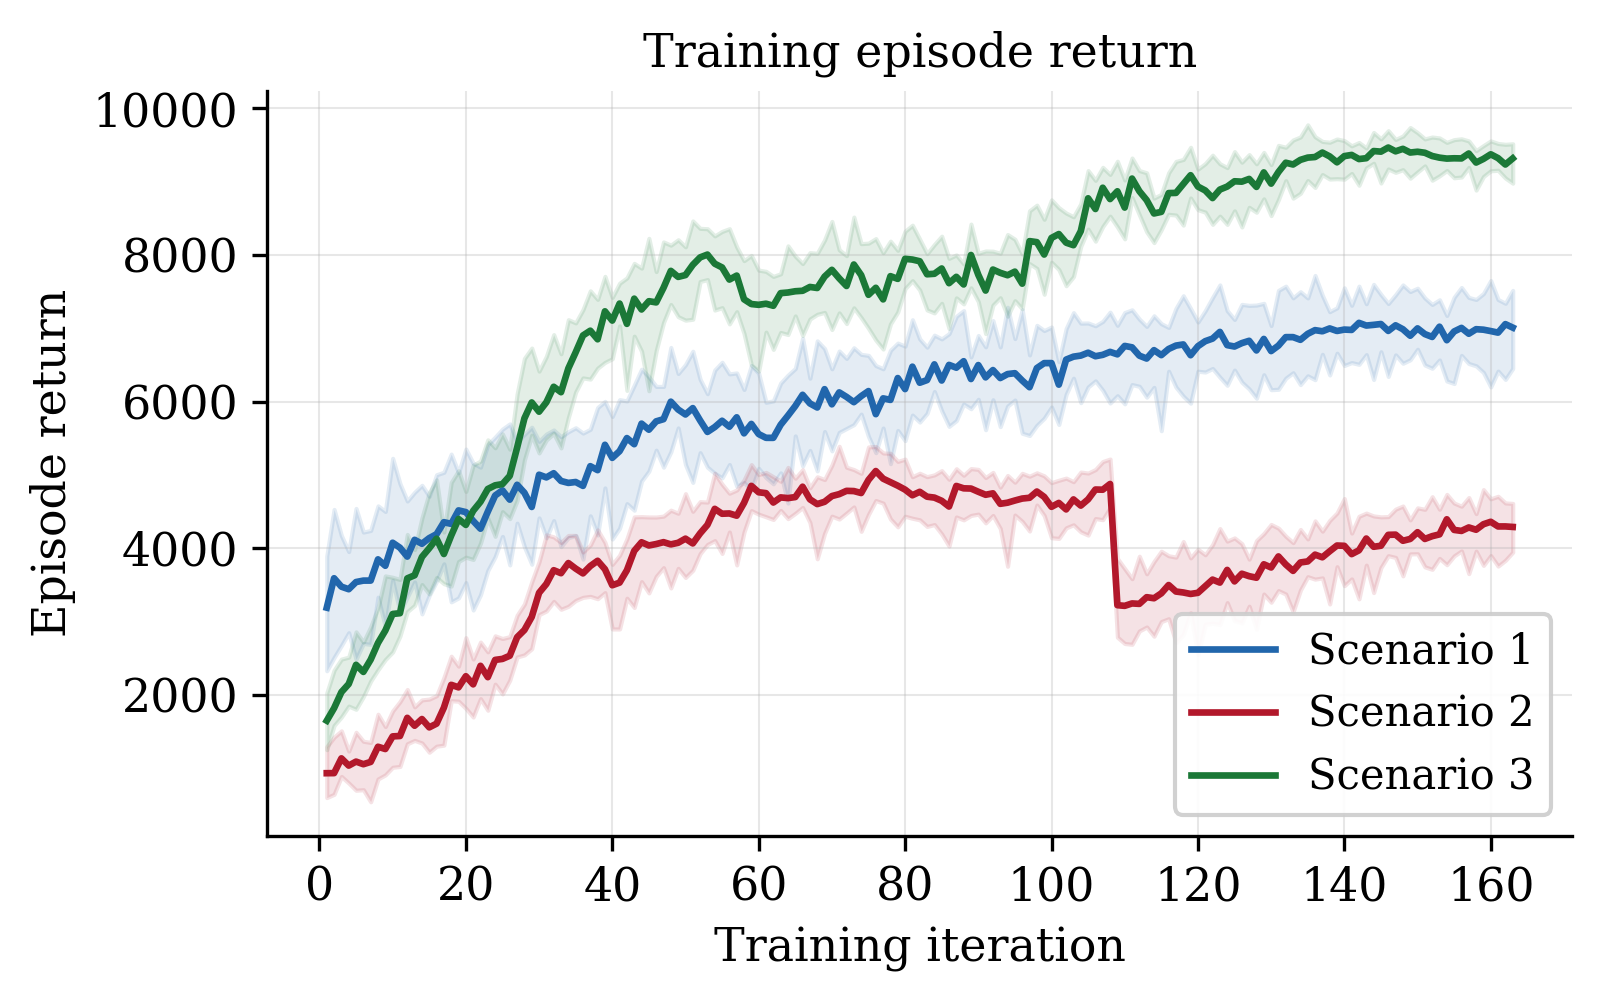

In [15]:
# ═══════════════════════════════════════════════════════════════════════

fig1, ax1 = plt.subplots(figsize=(5.5, 3.5))

for i, (key, label) in enumerate(zip(EXPERIMENTS.keys(), CASE_LABELS)):
    df, cm, cmin, cmax = train_data[key]
    x = (
        df["training_iteration"]
        if "training_iteration" in df.columns
        else np.arange(len(df))
    )
    color = CASE_COLORS[i]
    ax1.plot(x, df[cm], linewidth=1.6, color=color, label=label)
    ax1.fill_between(x, df[cmin], df[cmax], alpha=0.12, color=color)

ax1.set_xlabel("Training iteration")
ax1.set_ylabel("Episode return")
ax1.set_title("Training episode return")
ax1.legend(loc="lower right", framealpha=0.9)
fig1.tight_layout()
fig1.savefig("/home/juanbmedina/rllib/plots/fig_training_curves.pdf")
# fig1.savefig("/home/claude/fig_training_curves.png")
# plt.close(fig1)
plt.show()

## Section 15

In [16]:
# ═══════════════════════════════════════════════════════════════════════
# FIGURE 2 — Composite cumulative reward per agent + Gini index

## Section 16

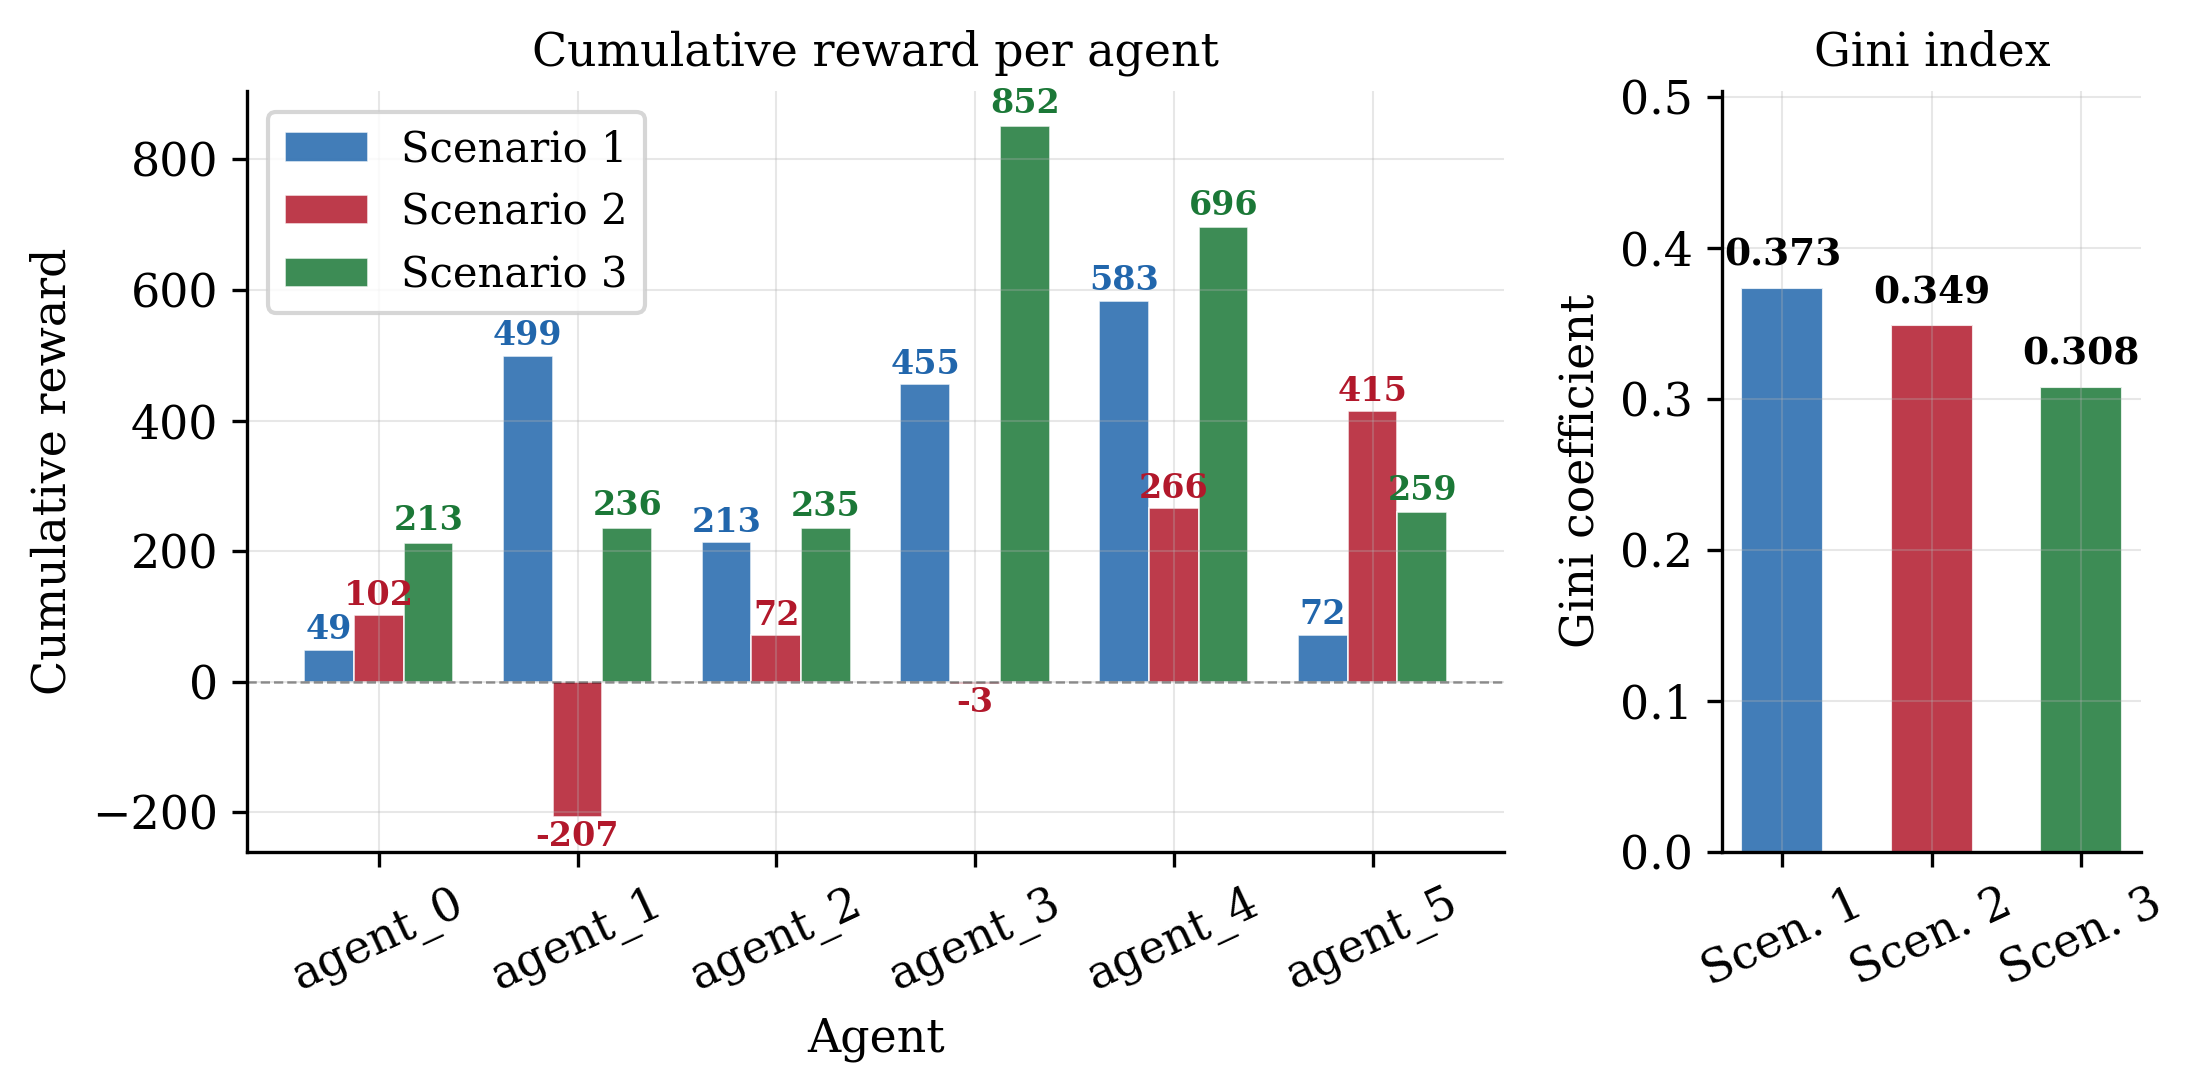

In [26]:
# ═══════════════════════════════════════════════════════════════════════

keys_list  = list(EXPERIMENTS.keys())
n_cases    = len(keys_list)

# Determine agents from first case
agents = list(eval_data[keys_list[0]][0].columns)
n_agents = len(agents)

fig2, (ax2a, ax2b) = plt.subplots(
    1, 2, figsize=(7.5, 3.8),
    gridspec_kw={"width_ratios": [3, 1]},
)

# ── Left: grouped bars of cumulative reward ──
x = np.arange(n_agents)
total_width = 0.75
bar_w = total_width / n_cases
offsets = np.linspace(-(n_cases - 1) / 2 * bar_w,
                       (n_cases - 1) / 2 * bar_w, n_cases)

gini_values = []

for i, key in enumerate(keys_list):
    rh = eval_data[key][0]
    cumulative = rh.sum()
    vals = cumulative.values
    gini_values.append(gini_coefficient(vals))

    bars = ax2a.bar(
        x + offsets[i], vals,
        width=bar_w, color=CASE_COLORS[i], alpha=0.85,
        label=CASE_LABELS[i], edgecolor="white", linewidth=0.4,
    )

    # value labels on top of each bar
    for bar, val in zip(bars, vals):
        va = "bottom" if val >= 0 else "top"
        off = 0.01 * max(abs(vals).max(), 1) * (1 if val >= 0 else -1)
        ax2a.text(
            bar.get_x() + bar.get_width() / 2, val + off,
            f"{val:.0f}", ha="center", va=va, fontsize=8,
            color=CASE_COLORS[i], fontweight="bold",
        )

ax2a.axhline(0, color="black", linewidth=0.6, linestyle="--", alpha=0.4)
ax2a.set_xticks(x)
ax2a.set_xticklabels(agents, rotation=25)
ax2a.set_xlabel("Agent")
ax2a.set_ylabel("Cumulative reward")
ax2a.set_title("Cumulative reward per agent")
ax2a.legend(loc="best")

# ── Right: Gini index bar chart ──
bar_gini = ax2b.bar(
    np.arange(n_cases), gini_values,
    color=CASE_COLORS, alpha=0.85,
    edgecolor="white", linewidth=0.5, width=0.55,
)
for bar, val in zip(bar_gini, gini_values):
    ax2b.text(
        bar.get_x() + bar.get_width() / 2, val + 0.01,
        f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold",
    )

ax2b.set_xticks(np.arange(n_cases))
ax2b.set_xticklabels(["Scen. 1", "Scen. 2", "Scen. 3"], rotation=25)
ax2b.set_ylabel("Gini coefficient")
ax2b.set_title("Gini index")
ax2b.set_ylim(0, max(gini_values) * 1.35 if max(gini_values) > 0 else 1.0)

fig2.tight_layout()
fig2.savefig("/home/juanbmedina/rllib/plots/fig_cumulative_reward_gini.pdf")
# fig2.savefig("/home/claude/fig_cumulative_reward_gini.png")
# plt.close(fig2)

plt.show()

## Section 17

In [18]:
# ═══════════════════════════════════════════════════════════════════════
# FIGURE 3 — Community energy daily totals (all 3 cases, single plot)
#
# Each case gets ONE overlapping-bar group (summed over all hours).
# The overlapping style is preserved: widest bar = generation,
# narrowest = export, with P2P, import in between.

## Section 18

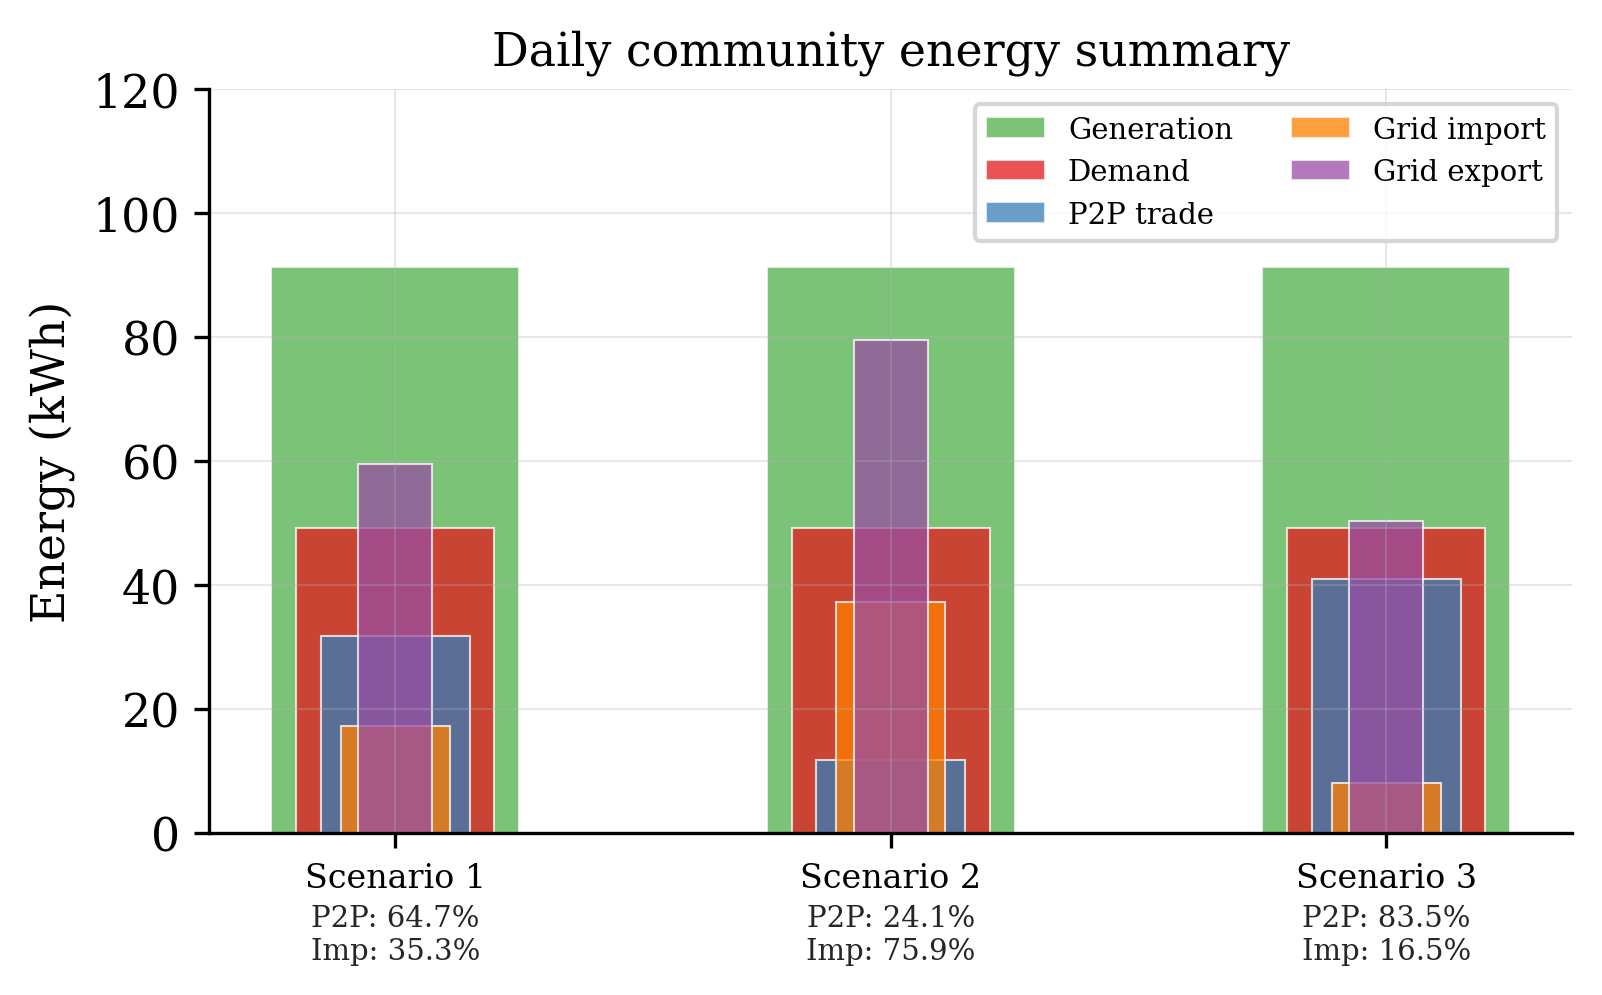

In [19]:
# ═══════════════════════════════════════════════════════════════════════

fig3, ax3 = plt.subplots(figsize=(5.5, 3.5))

# Metric definitions: (column, label, colour, relative_width_fraction)
metric_defs = [
    ("generation_total", "Generation",  "#4daf4a", 1.00),
    ("demand_total",     "Demand",      "#e41a1c", 0.80),
    ("total_p2p",        "P2P trade",   "#377eb8", 0.60),
    ("total_import",     "Grid import", "#ff7f00", 0.44),
    ("total_export",     "Grid export", "#984ea3", 0.30),
]

x_cases     = np.arange(n_cases)
max_width   = 0.50          # total bar footprint per case

for col, label, color, wfrac in metric_defs:
    w = max_width * wfrac
    vals = []
    for key in keys_list:
        ch = eval_data[key][1]
        vals.append(ch[col].sum() if col in ch.columns else 0.0)
    vals = np.array(vals)

    ax3.bar(
        x_cases, vals, width=w, color=color, alpha=0.75,
        label=label, edgecolor="white", linewidth=0.5,
    )

# ── Annotate P2P utilisation % on top of P2P bars ──
for i, key in enumerate(keys_list):
    ch = eval_data[key][1]
    gen_total = ch["generation_total"].sum()
    dem_total = ch["demand_total"].sum()
    p2p_total = ch["total_p2p"].sum()
    imp_total = ch["total_import"].sum()
    exp_total = ch["total_export"].sum()

    tradeable = min(gen_total, dem_total)
    pct_p2p    = (p2p_total / tradeable * 100) if tradeable > 1e-9 else 0.0
    pct_import = (imp_total / dem_total  * 100) if dem_total  > 1e-9 else 0.0
    pct_export = (exp_total / gen_total  * 100) if gen_total  > 1e-9 else 0.0

    # P2P % label on top of P2P bar
    # ax3.text(
    #     i, p2p_total + 0.3, f"P2P {pct_p2p:.1f}%",
    #     ha="center", va="bottom", fontsize=7,
    #     color="#377eb8", fontweight="bold",
    # )
    # Import % and Export % below
    y_base = -0.12 * ax3.get_ylim()[1] if ax3.get_ylim()[1] > 0 else -1
    ax3.text(
        i, y_base, f"P2P: {pct_p2p:.1f}%\nImp: {pct_import:.1f}%",
        ha="center", va="top", fontsize=7, color="0.15",
    )

ax3.set_xticks(x_cases)
ax3.set_xticklabels(CASE_LABELS, fontsize=8)
ax3.set_ylabel("Energy (kWh)")
ax3.set_ylim([0,120])
ax3.set_title("Daily community energy summary")
ax3.legend(loc="upper right", fontsize=7, ncol=2)

fig3.tight_layout()
fig3.savefig("/home/juanbmedina/rllib/plots/fig_community_energy_pct.pdf")
# fig3.savefig("/home/claude/fig_community_energy_pct.png")
# plt.close(fig3)

plt.show()

## FIGURE 4 — Mean clearing price over 24 h

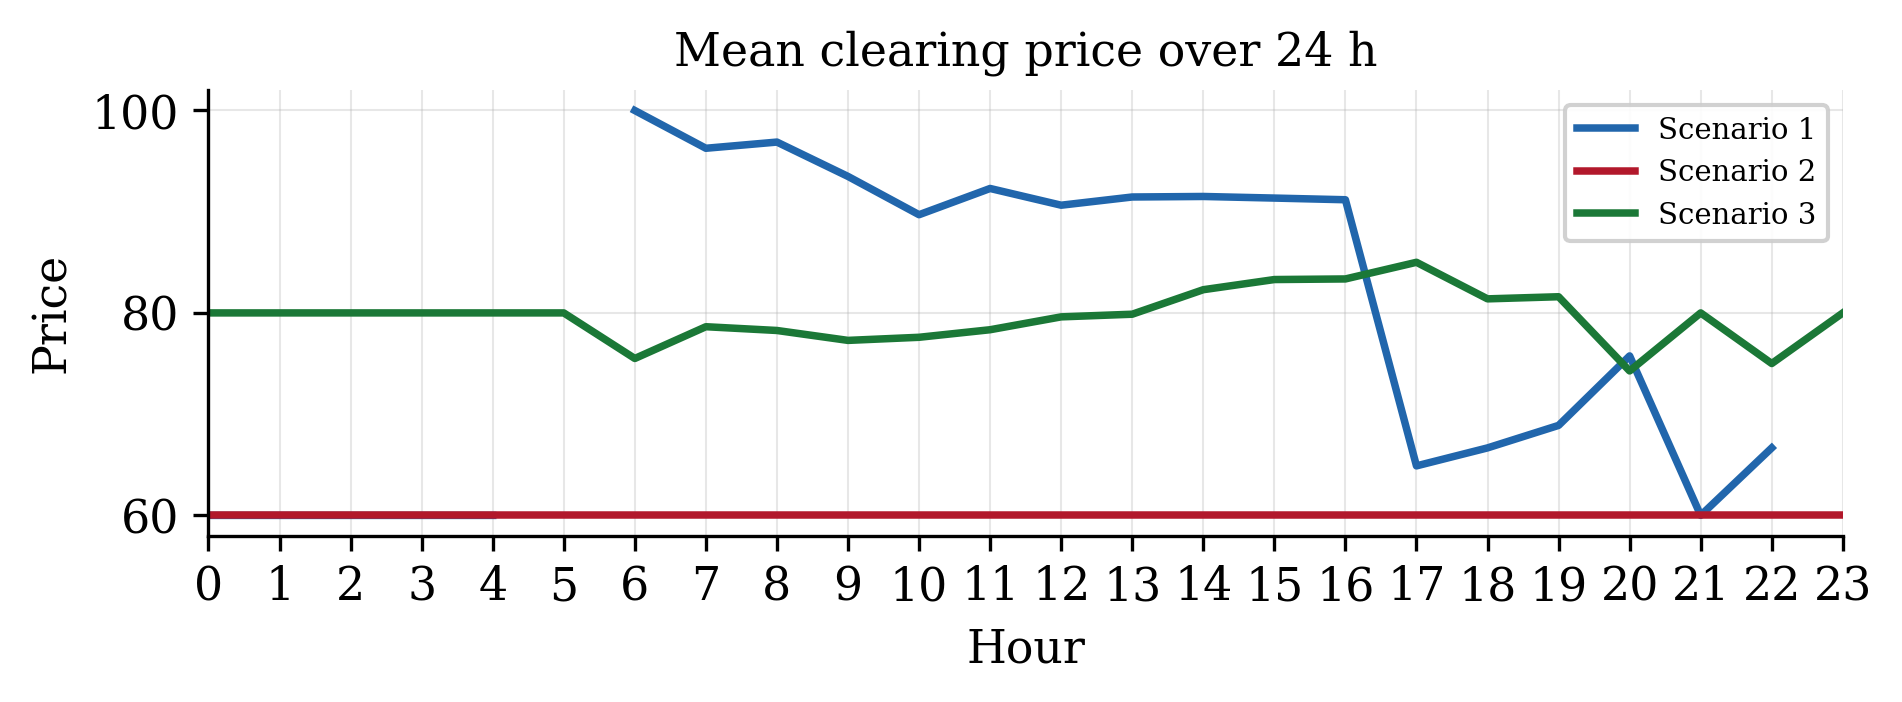

✓ Saved: fig_clearing_price.pdf / .png


In [20]:
# ═══════════════════════════════════════════════════════════════════════
# FIGURE 4 — Mean clearing price over 24 h (all three cases)
# ═══════════════════════════════════════════════════════════════════════

def _parse_matrix(x):
    """Parse a string-encoded NxN matrix into a numpy array."""
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return None
    if isinstance(x, np.ndarray):
        return x
    s = str(x).strip()
    if not s:
        return None
    try:
        v = ast.literal_eval(s)
        return np.array(v, dtype=float)
    except Exception:
        return None


def load_clearing_price(csv_path):
    """
    Read the evaluation CSV and return a Series indexed by hour_index
    with the mean clearing price (mean of non-zero entries in the M matrix).

    The M matrix is stored as a single string-encoded NxN list-of-lists
    in a column named 'M'.  Only entries where the corresponding P > 0
    are considered (i.e. actual P2P transactions).
    """
    df = pd.read_csv(csv_path)
    df["hour_index"] = pd.to_numeric(df["hour_index"], errors="coerce")

    def _row_clearing(row):
        M = _parse_matrix(row.get("M"))
        P = _parse_matrix(row.get("P"))
        if M is None:
            return np.nan
        if P is not None:
            # Only consider pairs where power was actually traded
            mask = P > 1e-9
        else:
            mask = M > 1e-9
        vals = M[mask]
        return float(np.mean(vals)) if len(vals) > 0 else np.nan

    df["clearing_mean"] = df.apply(_row_clearing, axis=1)

    by_hour = df.groupby("hour_index")["clearing_mean"].mean().sort_index()
    return by_hour


# ── Load clearing price for the three cases ─────────────────────────
clearing_data = {}
for key, exp_name in EXPERIMENTS.items():
    _, ep = _paths(exp_name)
    clearing_data[key] = load_clearing_price(ep)

# ── Plot ────────────────────────────────────────────────────────────
fig4, ax4 = plt.subplots(figsize=(6.5, 2.5))

for i, key in enumerate(keys_list):
    ch = clearing_data[key]
    hours = ch.index.values
    ax4.plot(hours, ch.values, linestyle="-", linewidth=1.8,
             color=CASE_COLORS[i], label=CASE_LABELS[i])

ax4.set_xlabel("Hour")
ax4.set_ylabel("Price")
ax4.set_title("Mean clearing price over 24 h")
ax4.set_xticks(np.arange(0, 24))
ax4.legend(fontsize=7, loc="best", framealpha=0.9)
ax4.set_xlim(0, 23)

fig4.tight_layout()
fig4.savefig("/home/juanbmedina/rllib/plots/fig_clearing_price.pdf")
# fig4.savefig("fig_clearing_price.png")
plt.show()
print("✓ Saved: fig_clearing_price.pdf / .png")


## Section 19

In [21]:
# ═══════════════════════════════════════════════════════════════════════
# TABLE — P2P utilization percentage per hour (for LaTeX)

## Section 20

In [22]:
# ═══════════════════════════════════════════════════════════════════════

print("\n" + "=" * 72)
print("P2P UTILISATION PERCENTAGE PER HOUR (of tradeable = min(gen, dem))")
print("=" * 72)

rows = []
for key in keys_list:
    ch = eval_data[key][1]
    tradeable = np.minimum(ch["generation_total"].values, ch["demand_total"].values)
    p2p = ch["total_p2p"].values
    imp = ch["total_import"].values
    exp = ch["total_export"].values
    with np.errstate(divide='ignore', invalid='ignore'):
        pct_p2p    = np.where(tradeable > 1e-9, p2p / tradeable * 100, 0.0)
        pct_import = np.where(ch["demand_total"].values > 1e-9,
                              imp / ch["demand_total"].values * 100, 0.0)
        pct_export = np.where(ch["generation_total"].values > 1e-9,
                              exp / ch["generation_total"].values * 100, 0.0)
    rows.append({"case": key, "hours": list(ch.index.astype(int)),
                 "p2p%": pct_p2p, "import%": pct_import, "export%": pct_export})

for r in rows:
    print(f"\n--- {r['case']} ---")
    for j, h in enumerate(r["hours"]):
        print(f"  h={h:2d}  P2P={r['p2p%'][j]:5.1f}%  Import={r['import%'][j]:5.1f}%  Export={r['export%'][j]:5.1f}%")


P2P UTILISATION PERCENTAGE PER HOUR (of tradeable = min(gen, dem))

--- base ---
  h= 0  P2P=100.0%  Import=  0.0%  Export= 99.0%
  h= 1  P2P=100.0%  Import=  0.0%  Export= 98.2%
  h= 2  P2P=100.0%  Import=  0.0%  Export= 98.5%
  h= 3  P2P=100.0%  Import=  0.0%  Export= 98.6%
  h= 4  P2P=100.0%  Import=  0.0%  Export= 98.4%
  h= 5  P2P=  0.0%  Import=100.0%  Export=100.0%
  h= 6  P2P= 69.5%  Import= 30.5%  Export= 42.7%
  h= 7  P2P=100.0%  Import= 23.7%  Export=  0.0%
  h= 8  P2P= 88.8%  Import= 22.3%  Export= 11.2%
  h= 9  P2P= 80.1%  Import= 19.9%  Export= 32.5%
  h=10  P2P= 83.9%  Import= 16.1%  Export= 33.9%
  h=11  P2P= 93.1%  Import=  6.9%  Export= 23.6%
  h=12  P2P= 74.2%  Import= 25.8%  Export= 31.3%
  h=13  P2P= 80.5%  Import= 19.5%  Export= 21.1%
  h=14  P2P= 84.7%  Import= 21.1%  Export= 15.3%
  h=15  P2P= 79.8%  Import= 31.7%  Export= 20.2%
  h=16  P2P= 78.1%  Import= 38.1%  Export= 21.9%
  h=17  P2P= 59.6%  Import= 60.5%  Export= 40.4%
  h=18  P2P= 44.0%  Import= 66.4%  E

## Section 21

In [23]:
# ═══════════════════════════════════════════════════════════════════════
# GINI summary

## Section 22

In [24]:
# ═══════════════════════════════════════════════════════════════════════

print("\n" + "=" * 72)
print("GINI COEFFICIENTS (cumulative reward)")
print("=" * 72)
for i, key in enumerate(keys_list):
    rh = eval_data[key][0]
    cum = rh.sum().values
    g = gini_coefficient(cum)
    print(f"  {CASE_LABELS[i]:>35s}:  Gini = {g:.4f}")


print("\n✓ Figures saved:")
print("  - fig_training_curves.pdf / .png")
print("  - fig_cumulative_reward_gini.pdf / .png")
print("  - fig_community_energy_pct.pdf / .png")


GINI COEFFICIENTS (cumulative reward)
                           Scenario 1:  Gini = 0.3734
                           Scenario 2:  Gini = 0.3488
                           Scenario 3:  Gini = 0.3078

✓ Figures saved:
  - fig_training_curves.pdf / .png
  - fig_cumulative_reward_gini.pdf / .png
  - fig_community_energy_pct.pdf / .png


In [1]:
"""
Bar chart of per-hour community energy: generation, demand, P2P trade,
grid import, grid export.

Two modes:
  1. AVERAGE across all seeds in a scenario directory.
     python3 plot_hourly_energy.py exp_results_repro/.../descentralized_exp

  2. SINGLE seed/run.
     python3 plot_hourly_energy.py exp_results_repro/.../descentralized_exp --seed 42
     python3 plot_hourly_energy.py exp_results_repro/.../descentralized_exp --seed 42 --run 1

Inputs:
  <scenario_dir>/
  ├── energy_market_training_seed42_run1/
  │   └── PPO_energy_market_run/
  │       └── evaluation_agent_states.csv
  ├── energy_market_training_seed43_run2/
  │   └── ...

  + agents_profiles_24h.json (default: ./profiles/agents_profiles_24h.json),
    used to compute hourly demand and generation totals (the eval CSV
    does not record D and G per agent, only the net via `cap`/`role_vec`).

Outputs:
  PNG (and optional CSV) saved next to the run for single-seed mode, or
  in <scenario_dir>/ for the multi-seed average. Override with --output.
"""

import argparse
import json
import sys
from pathlib import Path
from typing import List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Colors borrowed from the ISGT paper figure 3 for visual consistency.
COLORS = {
    "generation":  "#2ca02c",  # green
    "demand":      "#d62728",  # red
    "p2p":         "#1f77b4",  # blue
    "grid_import": "#ff7f0e",  # orange
    "grid_export": "#9467bd",  # purple
}


# =====================================================================
# Profiles (D / G per hour) from agents JSON
# =====================================================================

def load_agents_profiles(json_path: Path) -> Tuple[np.ndarray, np.ndarray, int]:
    """Sum consumer / generator profiles across agents to get total per hour.

    Returns (total_D, total_G, num_hours).
    """
    if not json_path.is_file():
        raise FileNotFoundError(
            f"agents profiles JSON not found: {json_path}\n"
            f"Pass --agents-json if it lives elsewhere."
        )

    with json_path.open() as f:
        data = json.load(f)

    cons, gen = [], []
    for name, p in data.items():
        cons.append(np.asarray(p["consumer_profile"], dtype=np.float32))
        gen.append(np.asarray(p["generator_profile"], dtype=np.float32))

    if not cons:
        raise ValueError(f"No agents found in {json_path}")

    cons_mat = np.stack(cons, axis=0)  # (n_agents, num_hours)
    gen_mat = np.stack(gen, axis=0)

    if cons_mat.shape != gen_mat.shape:
        raise ValueError(
            f"consumer / generator profile shapes differ: "
            f"{cons_mat.shape} vs {gen_mat.shape}"
        )

    total_D = cons_mat.sum(axis=0)
    total_G = gen_mat.sum(axis=0)
    num_hours = cons_mat.shape[1]
    return total_D, total_G, num_hours


# =====================================================================
# CSV aggregation
# =====================================================================

def aggregate_csv_per_seed(csv_path: Path, seed_label: str) -> pd.DataFrame:
    """Reduce one evaluation_agent_states.csv to per-hour means.

    Steps:
      1. Sum total_p2p / total_import / total_export across the
         steps_per_hour sub-steps of each (episode, hour_index).
      2. Average across episodes within this seed.

    Returns a DataFrame with columns: seed, hour_index, p2p, imp, exp.
    """
    df = pd.read_csv(csv_path)

    required = ["episode", "hour_index",
                "total_p2p", "total_import", "total_export"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{csv_path} missing columns: {missing}")

    # Sum sub-steps -> per-hour energy in each episode.
    per_ep_hour = df.groupby(["episode", "hour_index"], as_index=False).agg(
        p2p=("total_p2p", "sum"),
        imp=("total_import", "sum"),
        exp=("total_export", "sum"),
    )

    # Mean across episodes for this seed.
    per_hour = per_ep_hour.groupby("hour_index", as_index=False).agg(
        p2p=("p2p", "mean"),
        imp=("imp", "mean"),
        exp=("exp", "mean"),
    )
    per_hour["seed"] = seed_label
    return per_hour


def aggregate_across_seeds(per_seed_dfs: List[pd.DataFrame]) -> pd.DataFrame:
    """Average per-hour means across seeds. Returns DataFrame indexed by hour."""
    all_df = pd.concat(per_seed_dfs, ignore_index=True)
    per_hour = all_df.groupby("hour_index", as_index=True).agg(
        p2p=("p2p", "mean"),
        imp=("imp", "mean"),
        exp=("exp", "mean"),
    )
    return per_hour


# =====================================================================
# Discovery
# =====================================================================

def find_runs(
    scenario_dir: Path,
    seed_pattern: str,
    only_seed: Optional[str],
    only_run: Optional[str],
) -> List[Tuple[str, Path]]:
    """Find evaluation CSVs under scenario_dir.

    Returns list of (run_name, csv_path).
    """
    out = []
    for seed_dir in sorted(scenario_dir.glob(seed_pattern)):
        if not seed_dir.is_dir():
            continue
        if only_seed and f"seed{only_seed}_" not in seed_dir.name:
            continue
        if only_run and not seed_dir.name.endswith(f"_run{only_run}"):
            continue

        csv = seed_dir / "PPO_energy_market_run" / "evaluation_agent_states.csv"
        if csv.exists():
            out.append((seed_dir.name, csv))
        else:
            print(f"  WARN: missing {csv}")
    return out


# =====================================================================
# Plotting
# =====================================================================

def plot_hourly_summary(
    per_hour_df: pd.DataFrame,
    total_D: np.ndarray,
    total_G: np.ndarray,
    title: str,
    out_path: Path,
) -> None:
    """Grouped bar chart, 5 series per hour."""
    hours = per_hour_df.index.values.astype(int)

    if hours.max() >= len(total_D):
        raise ValueError(
            f"hour_index up to {hours.max()} found in eval CSV, but agents JSON "
            f"only has {len(total_D)} hours. Mismatched profile?"
        )
    D_per_h = total_D[hours]
    G_per_h = total_G[hours]
    p2p = per_hour_df["p2p"].values
    imp = per_hour_df["imp"].values
    exp = per_hour_df["exp"].values

    fig, ax = plt.subplots(figsize=(15, 6))
    width = 0.16
    x = np.arange(len(hours), dtype=float)

    ax.bar(x - 2 * width, G_per_h, width,
           label="Generation", color=COLORS["generation"])
    ax.bar(x - 1 * width, D_per_h, width,
           label="Demand", color=COLORS["demand"])
    ax.bar(x + 0 * width, p2p, width,
           label="P2P trade", color=COLORS["p2p"])
    ax.bar(x + 1 * width, imp, width,
           label="Grid import", color=COLORS["grid_import"])
    ax.bar(x + 2 * width, exp, width,
           label="Grid export", color=COLORS["grid_export"])

    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Energy (kWh)")
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{h}" for h in hours])
    ax.grid(axis="y", alpha=0.3)
    ax.legend(loc="upper right", ncol=5, framealpha=0.95)

    # Footer with daily totals (handy for sanity checking against fig. 3 of the PDF).
    total_p2p_day = float(p2p.sum())
    total_imp_day = float(imp.sum())
    total_exp_day = float(exp.sum())
    total_D_day = float(D_per_h.sum())
    total_G_day = float(G_per_h.sum())

    p2p_share_demand = (
        100.0 * total_p2p_day / total_D_day if total_D_day > 1e-9 else 0.0
    )
    imp_share_demand = (
        100.0 * total_imp_day / total_D_day if total_D_day > 1e-9 else 0.0
    )
    exp_share_gen = (
        100.0 * total_exp_day / total_G_day if total_G_day > 1e-9 else 0.0
    )

    summary = (
        f"Daily totals (kWh):  G={total_G_day:.1f}   D={total_D_day:.1f}   "
        f"P2P={total_p2p_day:.1f} ({p2p_share_demand:.1f}% of D)   "
        f"Imp={total_imp_day:.1f} ({imp_share_demand:.1f}% of D)   "
        f"Exp={total_exp_day:.1f} ({exp_share_gen:.1f}% of G)"
    )
    fig.text(0.5, 0.005, summary, ha="center", fontsize=9, color="#333333")

    plt.tight_layout(rect=[0, 0.03, 1, 1])
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=150)
    print(f"\nSaved figure to: {out_path}")
    plt.close(fig)


# =====================================================================
# Main
# =====================================================================

def main():
    parser = argparse.ArgumentParser(
        description="Hourly community-energy bar chart from evaluation CSVs."
    )
    parser.add_argument(
        "scenario_dir",
        help="Path to a scenario folder (containing energy_market_training_seed*_run*/ subfolders).",
    )
    parser.add_argument(
        "--agents-json", default="profiles/agents_profiles_24h.json",
        help="Path to agents_profiles_24h.json "
             "(default: profiles/agents_profiles_24h.json relative to cwd).",
    )
    parser.add_argument(
        "--seed", default=None,
        help='Filter to a single seed (e.g. "42"). If omitted, averages across all seeds.',
    )
    parser.add_argument(
        "--run", default=None,
        help='Optional run-index filter (e.g. "1"). Only meaningful with --seed.',
    )
    parser.add_argument(
        "--seed-glob", default="energy_market_training_seed*_run*",
        help="Pattern for seed-run folders inside scenario_dir.",
    )
    parser.add_argument(
        "--output", default=None,
        help="Output PNG path. Auto-named if omitted.",
    )
    parser.add_argument(
        "--save-csv", action="store_true",
        help="Also save the aggregated per-hour data as CSV next to the PNG.",
    )
    parser.add_argument(
        "--show", action="store_true",
        help="Open the figure window instead of just saving.",
    )
    args = parser.parse_args()

    scenario_dir = Path(args.scenario_dir).resolve()
    if not scenario_dir.is_dir():
        sys.exit(f"scenario_dir not found: {scenario_dir}")

    agents_json = Path(args.agents_json).resolve()
    total_D, total_G, num_hours = load_agents_profiles(agents_json)
    print(f"Loaded agent profiles: {len(total_D)} hours from {agents_json}")
    print(f"  total_G(day) = {total_G.sum():.2f} kWh   "
          f"total_D(day) = {total_D.sum():.2f} kWh")

    runs = find_runs(scenario_dir, args.seed_glob, args.seed, args.run)
    if not runs:
        sys.exit(
            f"No evaluation_agent_states.csv found under {scenario_dir} "
            f"(seed={args.seed!r}, run={args.run!r})."
        )

    print(f"\nFound {len(runs)} run(s):")
    for label, csv in runs:
        print(f"  - {label}  ({csv})")

    # ---------------- Aggregate ----------------
    per_seed_dfs = []
    for label, csv in runs:
        try:
            per_seed_dfs.append(aggregate_csv_per_seed(csv, label))
        except Exception as e:
            print(f"  ERROR processing {label}: {e!r}")

    if not per_seed_dfs:
        sys.exit("No usable runs after aggregation. Aborting.")

    # Decide single vs. average mode strictly from how many runs survived.
    if len(per_seed_dfs) == 1:
        run_label = per_seed_dfs[0]["seed"].iloc[0]
        per_hour = (per_seed_dfs[0]
                    .drop(columns=["seed"])
                    .set_index("hour_index"))
        title = (f"Hourly community-energy summary  ·  {scenario_dir.name}  ·  "
                 f"{run_label}")
        default_out_dir = scenario_dir / run_label / "PPO_energy_market_run"
        default_stem = f"hourly_energy_{run_label}"
    else:
        per_hour = aggregate_across_seeds(per_seed_dfs)
        title = (f"Hourly community-energy summary  ·  {scenario_dir.name}  ·  "
                 f"average over {len(per_seed_dfs)} seeds")
        default_out_dir = scenario_dir
        default_stem = f"hourly_energy_avg_{len(per_seed_dfs)}seeds"

    # ---------------- Save outputs ----------------
    if args.output:
        out_path = Path(args.output).resolve()
    else:
        out_path = default_out_dir / f"{default_stem}.png"

    plot_hourly_summary(per_hour, total_D, total_G, title, out_path)

    if args.save_csv:
        # Add the matching D/G per hour for reproducibility.
        out_df = per_hour.copy()
        out_df["generation"] = total_G[per_hour.index.values.astype(int)]
        out_df["demand"] = total_D[per_hour.index.values.astype(int)]
        out_df = out_df[["generation", "demand", "p2p", "imp", "exp"]]
        out_df.columns = [
            "generation", "demand", "p2p_trade", "grid_import", "grid_export",
        ]
        csv_out = out_path.with_suffix(".csv")
        out_df.to_csv(csv_out)
        print(f"Saved aggregated CSV to: {csv_out}")

    if args.show:
        # Reload and show — already saved above.
        img = plt.imread(out_path)
        plt.figure(figsize=(15, 6))
        plt.imshow(img)
        plt.axis("off")
        plt.show()


if __name__ == "__main__":
    main()

usage: ipykernel_launcher.py [-h] [--agents-json AGENTS_JSON] [--seed SEED]
                             [--run RUN] [--seed-glob SEED_GLOB]
                             [--output OUTPUT] [--save-csv] [--show]
                             scenario_dir
ipykernel_launcher.py: error: the following arguments are required: scenario_dir


SystemExit: 2

/home/juanbmedina/rllib/rllib_venv/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3516: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
